# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang | 5054251038 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv("insurance.csv")
print(f"Ukuran dataset: {df.shape}")

Ukuran dataset: (1338, 7)


In [3]:
# Tampilkan beberapa baris pertama dataset.
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
# Periksa missing value.
print("Jumlah missing value per kolom:")
display(df.isnull().sum().to_frame("missing_value"))

Jumlah missing value per kolom:


,missing_value
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
# Tampilkan statistik deskriptif fitur numerik.
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [7]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
categorical_cols_eda = df.select_dtypes(include="object").columns
for col in categorical_cols_eda:
    print(f"\n{col}:")
    display(df[col].value_counts().to_frame("jumlah"))


sex:


C:\Users\Jordan\AppData\Local\Temp\ipykernel_7712\3683225480.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_eda = df.select_dtypes(include="object").columns


,jumlah
sex,
male,676
female,662



smoker:


,jumlah
smoker,
no,1064
yes,274



region:


,jumlah
region,
southeast,364
southwest,325
northwest,325
northeast,324


## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


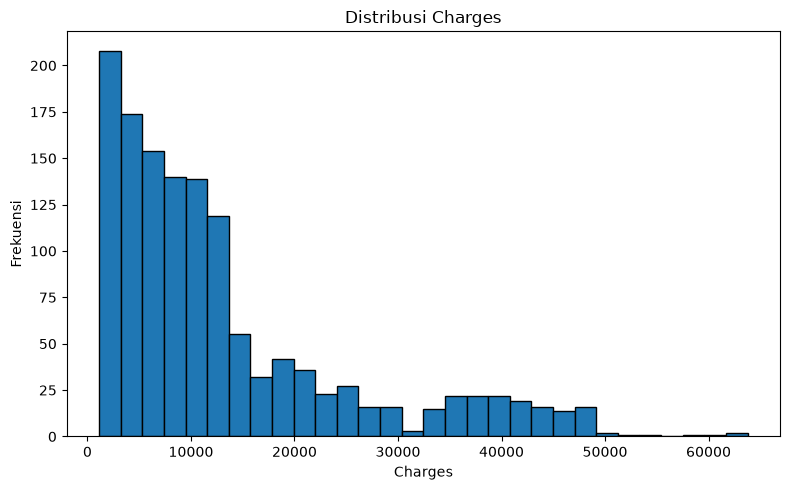

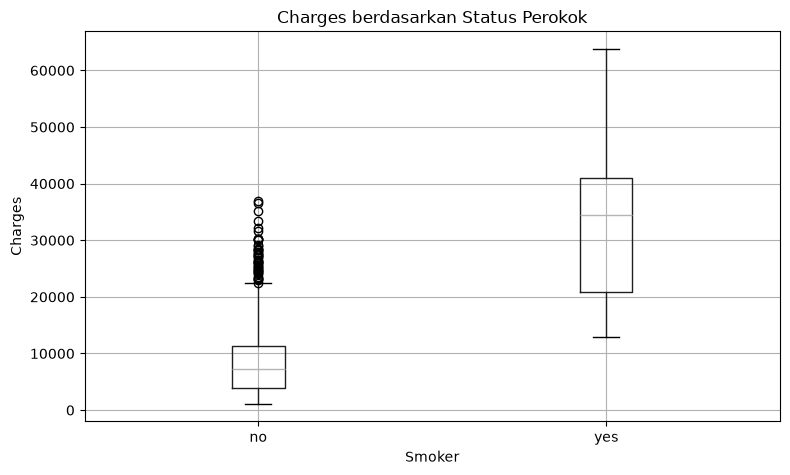

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['charges'], bins=30, edgecolor='black')
ax.set_title('Distribusi Charges')
ax.set_xlabel('Charges')
ax.set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='charges', by='smoker', ax=ax)
ax.set_title('Charges berdasarkan Status Perokok')
ax.set_xlabel('Smoker')
ax.set_ylabel('Charges')
fig.suptitle('')
plt.tight_layout()
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [9]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns=["charges"])
y = df["charges"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1338, 6)
Shape y: (1338,)


In [10]:
# Identifikasi kolom numerik dan kategorikal.
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Fitur numerik      :", numeric_cols)
print("Fitur kategorikal  :", categorical_cols)

Fitur numerik      : ['age', 'bmi', 'children']
Fitur kategorikal  : ['sex', 'smoker', 'region']


C:\Users\Jordan\AppData\Local\Temp\ipykernel_7712\2587861412.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [11]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (1070, 6)
Data test : (268, 6)


In [12]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# Untuk Decision Tree, scaling tidak diperlukan, tetapi encoding tetap digunakan.
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [13]:
# Inisialisasi dan latih Linear Regression.
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [14]:
# Lakukan prediksi pada test set.
y_pred_linear = linear_model.predict(X_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [15]:
# Buat fitur polynomial dan latih model.
poly_candidates = {}
for degree in [1, 2, 3]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", Ridge(alpha=1.0))
    ])
    search = GridSearchCV(
        pipe,
        param_grid={"model__alpha": [0.1, 1.0, 10.0]},
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    poly_candidates[degree] = (search.best_score_, search.best_estimator_, search.best_params_)

best_degree = max(poly_candidates, key=lambda d: poly_candidates[d][0])
polynomial_model = poly_candidates[best_degree][1]

print("Degree terbaik:", best_degree)
print("Parameter terbaik:", poly_candidates[best_degree][2])
print("CV RMSE terbaik:", -poly_candidates[best_degree][0])

Degree terbaik: 2
Parameter terbaik: {'model__alpha': 1.0}
CV RMSE terbaik: 4916.712284349077


In [16]:
# Lakukan prediksi pada test set.
y_pred_poly = polynomial_model.predict(X_test)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [17]:
# Inisialisasi dan latih Ridge Regression.
ridge_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)
ridge_model = ridge_search.best_estimator_

print("Alpha Ridge terbaik:", ridge_search.best_params_["model__alpha"])
print("CV RMSE:", -ridge_search.best_score_)

Alpha Ridge terbaik: 1
CV RMSE: 6146.993986947508


In [18]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge_model.predict(X_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [19]:
# Inisialisasi dan latih Lasso Regression.
lasso_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=100000, random_state=42))
    ]),
    param_grid={"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)
lasso_model = lasso_search.best_estimator_

print("Alpha Lasso terbaik:", lasso_search.best_params_["model__alpha"])
print("CV RMSE:", -lasso_search.best_score_)

Alpha Lasso terbaik: 100
CV RMSE: 6137.114865047652


In [20]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso_model.predict(X_test)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [21]:
# Inisialisasi dan latih Decision Tree Regressor.
tree_search = GridSearchCV(
    Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    param_grid={
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 2, 5, 10]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
tree_search.fit(X_train, y_train)
tree_model = tree_search.best_estimator_

print("Parameter Decision Tree terbaik:", tree_search.best_params_)
print("CV RMSE:", -tree_search.best_score_)

Parameter Decision Tree terbaik: {'model__max_depth': 3, 'model__min_samples_leaf': 1}
CV RMSE: 4805.626232269798


In [22]:
# Lakukan prediksi pada test set.
y_pred_tree = tree_model.predict(X_test)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [23]:
# Inisialisasi dan latih SVR.
svr_search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVR(kernel="rbf"))
    ]),
    param_grid={
        "model__C": [10, 100, 1000],
        "model__gamma": ["scale", 0.01, 0.1],
        "model__epsilon": [0.1, 0.5]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
svr_search.fit(X_train, y_train)
svr_model = svr_search.best_estimator_

print("Parameter SVR terbaik:", svr_search.best_params_)
print("CV RMSE:", -svr_search.best_score_)

Parameter SVR terbaik: {'model__C': 1000, 'model__epsilon': 0.1, 'model__gamma': 'scale'}
CV RMSE: 7453.3565908392775


In [24]:
# Lakukan prediksi pada test set.
y_pred_svr = svr_model.predict(X_test)

# 4. Evaluasi Model

In [25]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
predictions = {
    "Linear Regression": y_pred_linear,
    "Polynomial Regression": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Decision Tree Regressor": y_pred_tree,
    "Support Vector Regression": y_pred_svr
}

results = []
for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R²"]
).sort_values("RMSE").reset_index(drop=True)

display(results_df.round(2))

,Model,MAE,MSE,RMSE,R²
0,Polynomial Regression,2732.79,20705051.85,4550.28,0.87
1,Decision Tree Regressor,2865.64,22812669.85,4776.26,0.85
2,Linear Regression,4181.19,33596915.85,5796.28,0.78
3,Ridge Regression,4186.91,33620268.92,5798.30,0.78
4,Lasso Regression,4246.63,34250141.89,5852.36,0.78
5,Support Vector Regression,3014.46,47916582.76,6922.18,0.69


In [26]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
best = results_df.iloc[0]
worst = results_df.iloc[-1]
print(f"Model terbaik berdasarkan RMSE: {best['Model']} (RMSE={best['RMSE']:.2f}, R²={best['R²']:.4f})")
print(f"Model dengan RMSE tertinggi: {worst['Model']} (RMSE={worst['RMSE']:.2f}, R²={worst['R²']:.4f})")
print("\nUrutan model berdasarkan RMSE:")
for rank, row in results_df.iterrows():
    print(f"{rank+1}. {row['Model']}: RMSE={row['RMSE']:.2f}, MAE={row['MAE']:.2f}, R²={row['R²']:.4f}")

Model terbaik berdasarkan RMSE: Polynomial Regression (RMSE=4550.28, R²=0.8666)
Model dengan RMSE tertinggi: Support Vector Regression (RMSE=6922.18, R²=0.6914)

Urutan model berdasarkan RMSE:
1. Polynomial Regression: RMSE=4550.28, MAE=2732.79, R²=0.8666
2. Decision Tree Regressor: RMSE=4776.26, MAE=2865.64, R²=0.8531
3. Linear Regression: RMSE=5796.28, MAE=4181.19, R²=0.7836
4. Ridge Regression: RMSE=5798.30, MAE=4186.91, R²=0.7834
5. Lasso Regression: RMSE=5852.36, MAE=4246.63, R²=0.7794
6. Support Vector Regression: RMSE=6922.18, MAE=3014.46, R²=0.6914


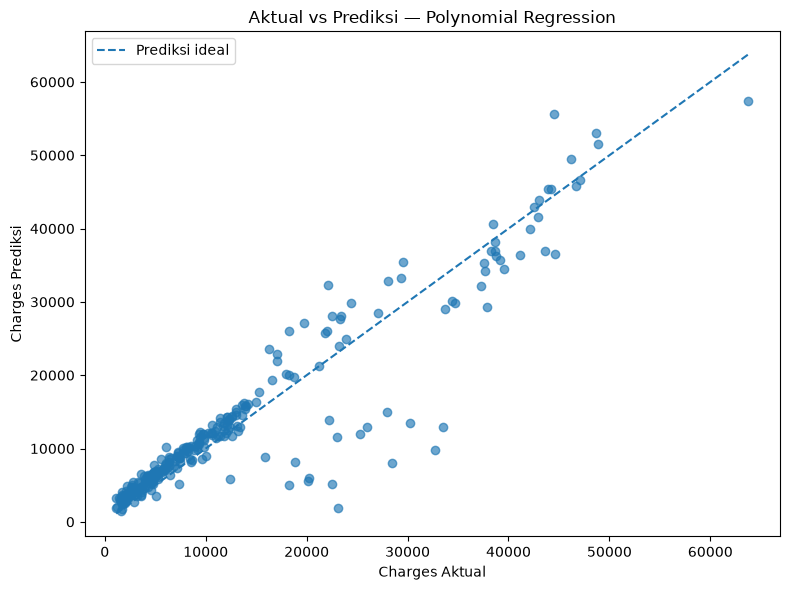

In [27]:
best_model_name = results_df.loc[0, 'Model']
best_pred = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_pred, alpha=0.65)
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], '--', label='Prediksi ideal')
ax.set_xlabel('Charges Aktual')
ax.set_ylabel('Charges Prediksi')
ax.set_title(f'Aktual vs Prediksi — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


Berdasarkan hasil evaluasi pada data test, performa keenam model dapat dibandingkan sebagai berikut:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Polynomial Regression | 2732,79 | 4550,28 | 0,8666 |
| Decision Tree Regressor | 2865,64 | 4776,26 | 0,8531 |
| Linear Regression | 4181,19 | 5796,28 | 0,7836 |
| Ridge Regression | 4186,91 | 5798,30 | 0,7834 |
| Lasso Regression | 4246,63 | 5852,36 | 0,7794 |
| Support Vector Regression | 3014,46 | 6922,18 | 0,6914 |

**Polynomial Regression** memberikan hasil terbaik karena memiliki RMSE paling kecil (4550,28) dan R² paling tinggi (0,8666). Artinya, model ini menghasilkan kesalahan prediksi paling rendah dan mampu menjelaskan sekitar 86,66% variasi nilai `charges` pada data test.

Decision Tree Regressor menjadi model kedua terbaik. Hasilnya cukup dekat dengan Polynomial Regression dan tidak memerlukan scaling. Sementara itu, Linear Regression, Ridge, dan Lasso memberikan performa yang relatif mirip. Ridge dan Lasso tidak memberikan peningkatan berarti dibanding Linear Regression pada dataset ini.

SVR menghasilkan MAE yang masih cukup rendah, tetapi RMSE paling tinggi. Hal ini menunjukkan terdapat beberapa prediksi dengan kesalahan yang cukup besar sehingga RMSE menjadi tinggi.

Preprocessing juga berpengaruh terhadap model. Fitur kategorikal `sex`, `smoker`, dan `region` diubah menggunakan OneHotEncoder. Scaling diterapkan pada model yang sensitif terhadap skala fitur, sedangkan Decision Tree menggunakan data tanpa scaling. Pemilihan hyperparameter dilakukan dengan 5-fold cross-validation pada data train sehingga data test tetap digunakan khusus untuk evaluasi akhir.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


Berdasarkan eksperimen, seluruh model berhasil digunakan untuk memprediksi `charges`. Model terbaik adalah **Polynomial Regression** dengan RMSE **4550,28**, MAE **2732,79**, dan R² **0,8666**. Hasil ini menunjukkan bahwa hubungan antara fitur dengan biaya asuransi tidak sepenuhnya linear sehingga penambahan fitur polynomial dapat meningkatkan kemampuan model dalam menangkap pola data.

Sebagai saran, eksperimen berikutnya dapat dilakukan dengan memperluas pencarian hyperparameter, mencoba model ensemble seperti Random Forest atau Gradient Boosting, serta melakukan feature engineering seperti interaksi antara `age`, `bmi`, dan `smoker`. Pengujian dengan beberapa random split atau cross-validation tambahan juga dapat digunakan untuk melihat kestabilan performa model.